In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
import lightgbm as lgb
import optuna

# optional: SMOTE (imbalance-learn)
try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False

### 파일 불러오기

In [4]:
users = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/users_EDA.csv')
events = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/events_EDA.csv')
orders = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/orders_EDA.csv')

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12644\1429863484.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  users = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/users_EDA.csv')


### 기본 컬럼 확인

In [7]:
assert 'id' in users.columns, "users에 id 컬럼 없음"
assert 'user_id' in events.columns, "events에 user_id 컬럼 없음"
assert 'user_id' in orders.columns, "orders에 user_id 컬럼 없음"

### 타겟 생성 (0,1,2,3+)

In [10]:
order_counts = orders.groupby('user_id').size().reset_index(name='order_count')
order_counts['order_count'] = order_counts['order_count'].clip(upper=3)  # 3 이상은 3
# 안전한 merge: users.id 와 order_counts.user_id
if 'user_id' in users.columns:
    users = users.drop(columns=['user_id'])  # 만약 존재하면 제거
users = users.merge(order_counts[['user_id','order_count']], left_on='id', right_on='user_id', how='left')
if 'user_id' in users.columns:
    users = users.drop(columns=['user_id'])
users['order_count'] = users['order_count'].fillna(0).astype(int)  # target


###  Feature Engineering

In [13]:
# 안전한 datetime 변환 (timezone/microseconds 처리)
users['created_at'] = pd.to_datetime(users['created_at'], errors='coerce', utc=True)
events['created_at'] = pd.to_datetime(events['created_at'], errors='coerce', utc=True)

# first_event: 가입 이후의 첫 이벤트 시간 (events -> user)
first_event = events.groupby('user_id')['created_at'].min().reset_index()
first_event.rename(columns={'created_at':'created_at_first_event'}, inplace=True)
# merge
users = users.merge(first_event[['user_id','created_at_first_event']], left_on='id', right_on='user_id', how='left')
if 'user_id' in users.columns:
    users = users.drop(columns=['user_id'])
users['created_at_first_event'] = pd.to_datetime(users['created_at_first_event'], errors='coerce', utc=True)

# days_to_first_event: 가입~첫이벤트(일) (가입 이후 이벤트가 없으면 -1)
users['days_to_first_event'] = (users['created_at_first_event'] - users['created_at']).dt.days
users['days_to_first_event'] = users['days_to_first_event'].fillna(-1).astype(int)

In [15]:
# session_count, unique_event_types (events 요약)
session_count = events.groupby('user_id')['session_id'].nunique().reset_index().rename(columns={'session_id':'session_count'})
event_diversity = events.groupby('user_id')['event_type'].nunique().reset_index().rename(columns={'event_type':'unique_event_types'})
users = users.merge(session_count, left_on='id', right_on='user_id', how='left'); users = users.drop(columns=['user_id'], errors='ignore')
users = users.merge(event_diversity, left_on='id', right_on='user_id', how='left'); users = users.drop(columns=['user_id'], errors='ignore')
users['session_count'] = users['session_count'].fillna(0).astype(int)
users['unique_event_types'] = users['unique_event_types'].fillna(0).astype(int)

In [17]:
# 가입 시점으로부터의 연/월/weekday 등 파생
users['reg_year'] = users['created_at'].dt.year.fillna(-1).astype(int)
users['reg_month'] = users['created_at'].dt.month.fillna(-1).astype(int)
users['reg_weekday'] = users['created_at'].dt.weekday.fillna(-1).astype(int)
users['reg_hour'] = users['created_at'].dt.hour.fillna(-1).astype(int)

In [19]:
# 연령대(예: 10대,20대...) 파생
users['age_group'] = pd.cut(users['age'].fillna(-1), bins=[-1,17,24,34,44,54,64,200],
                            labels=['unknown','10s','20s','30s','40s','50s','60+'])


### 인코딩 (라벨인코딩)

In [22]:
# 범주형: gender, traffic_source, age_group
for col in ['gender','traffic_source','age_group']:
    if col in users.columns:
        users[col] = users[col].astype(str)
        le = LabelEncoder()
        users[col] = le.fit_transform(users[col])

### 피처 선택 후보 지정

In [25]:
feature_cols = [
    'age', 'gender', 'traffic_source', 'days_to_first_event',
    'session_count', 'unique_event_types',
    'reg_year', 'reg_month', 'reg_weekday', 'reg_hour', 'age_group'
]
# 보장: 없는 컬럼은 생성(결측 처리)
for c in feature_cols:
    if c not in users.columns:
        users[c] = -1

X = users[feature_cols].fillna(-1)
y = users['order_count']

### 클래스 불균형 처리

In [29]:
def apply_smote(X_train, y_train):
    if not IMBLEARN_AVAILABLE:
        raise RuntimeError("imblearn 설치 필요: pip install imbalanced-learn")
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    return X_res, y_res

### Feature Selection: SelectFromModel(LGBM) 또는 중요도 기반 제거

In [32]:
def select_features_with_lgb(X_train, y_train, threshold='median'):
    # 간단한 LGBM 모델로 중요도 학습 후 선택
    dtrain = lgb.Dataset(X_train, label=y_train)
    params = {'objective':'multiclass','num_class':4,'metric':'multi_logloss','verbosity':-1}
    mdl = lgb.train(params, dtrain, num_boost_round=100, callbacks=[lgb.log_evaluation(period=0)])
    gain = mdl.feature_importance(importance_type='gain')
    feat_imp = pd.Series(gain, index=X_train.columns).sort_values(ascending=False)
    if isinstance(threshold, str) and threshold=='median':
        thr = feat_imp.median()
    else:
        thr = float(threshold)
    selected = feat_imp[feat_imp >= thr].index.tolist()
    return selected, feat_imp


### Cross-validated Training + Evaluation (Stratified K-Fold)

In [40]:
def cv_train_evaluate(X, y, lgb_params, n_splits=5, use_smote=False):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_preds = np.zeros((len(X), 4))  # num_class=4
    scores = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        # optional: SMOTE on training fold
        if use_smote:
            X_tr_res, y_tr_res = apply_smote(X_tr, y_tr)
        else:
            X_tr_res, y_tr_res = X_tr, y_tr

        dtr = lgb.Dataset(X_tr_res, label=y_tr_res)
        dval = lgb.Dataset(X_val, label=y_val)

        model = lgb.train(
            lgb_params,
            dtr,
            num_boost_round=1000,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
        )
        preds = model.predict(X_val, num_iteration=model.best_iteration)
        oof_preds[val_idx] = preds
        y_pred = preds.argmax(axis=1)
        macro_f1 = f1_score(y_val, y_pred, average='macro')
        bal_acc = balanced_accuracy_score(y_val, y_pred)
        scores.append({'fold':fold, 'macro_f1':macro_f1, 'balanced_acc':bal_acc})
        print(f"Fold {fold}: macro_f1={macro_f1:.4f}, balanced_acc={bal_acc:.4f}")

    # 전체 지표
    y_oof = oof_preds.argmax(axis=1)
    overall_macro = f1_score(y, y_oof, average='macro')
    overall_bal = balanced_accuracy_score(y, y_oof)
    print("OOF overall macro F1:", overall_macro)
    print("OOF overall Balanced Accuracy:", overall_bal)
    return oof_preds, pd.DataFrame(scores), overall_macro, overall_bal

 ### Optuna 하이퍼튜닝

In [43]:
def optuna_tune(X, y, n_trials=30, n_splits=3, use_smote=False):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    def objective(trial):
        param = {
            'objective':'multiclass',
            'num_class':4,
            'metric':'multi_logloss',
            'verbosity':-1,
            'boosting_type':'gbdt',
            'seed':42,
            'num_leaves': trial.suggest_int('num_leaves', 16, 128),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 200),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
            'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 5.0),
            'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 5.0)
        }

        cv_scores = []
        for tr_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
            if use_smote:
                X_tr, y_tr = apply_smote(X_tr, y_tr)
            dtrain = lgb.Dataset(X_tr, label=y_tr)
            dval = lgb.Dataset(X_val, label=y_val)
            mdl = lgb.train(param, dtrain, num_boost_round=1000,
                            valid_sets=[dval],
                            callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)])
            preds = mdl.predict(X_val, num_iteration=mdl.best_iteration).argmax(axis=1)
            cv_scores.append(f1_score(y_val, preds, average='macro'))
        return np.mean(cv_scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    print("Best trial accuracy (macro F1):", study.best_value)
    print("Best params:", study.best_params)
    return study.best_params

###  Stacking

In [46]:
def stacking_train(X, y, base_params, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_base = np.zeros((len(X), 4))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        dtr = lgb.Dataset(X_tr, label=y_tr)
        dval = lgb.Dataset(X_val, label=y_val)
        mdl = lgb.train(base_params, dtr, num_boost_round=1000,
                        valid_sets=[dval], callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)])
        preds = mdl.predict(X_val, num_iteration=mdl.best_iteration)
        oof_base[val_idx] = preds

    # meta training (use OOF preds as features)
    meta_X = oof_base
    meta_y = y.values
    meta_clf = LogisticRegression(max_iter=1000)
    meta_clf.fit(meta_X, meta_y)
    return meta_clf, oof_base


### Pseudo-labeling

In [49]:
def pseudo_labeling(final_model, X_unlabeled, threshold=0.95):
    # final_model: 학습된 lgb 모델
    probs = final_model.predict(X_unlabeled)
    max_probs = probs.max(axis=1)
    pseudo_idx = np.where(max_probs >= threshold)[0]
    pseudo_labels = probs[pseudo_idx].argmax(axis=1)
    return pseudo_idx, pseudo_labels

### 모델학습

In [66]:
# A) feature selection (간단)
selected_feats, feat_imp = select_features_with_lgb(X, y, threshold='median')
print("Selected features:", selected_feats)

# B) Optuna로 하이퍼파라미터 탐색 (use_smote=False 또는 True 선택)
best_params = optuna_tune(X[selected_feats], y, n_trials=10, n_splits=3, use_smote=False)  # 여기 n_trials=10 으로 변경

# C) cross-validated training + OOF 평가 (use_smote optional)
# prepare params for final CV training
lgb_params = best_params.copy()
lgb_params.update({'objective':'multiclass','num_class':4,'metric':'multi_logloss','verbosity':-1,'seed':42})
oof_preds, fold_scores, overall_macro, overall_bal = cv_train_evaluate(X[selected_feats], y, lgb_params, n_splits=5, use_smote=False)

# D) stacking meta model (optional)
meta_clf, oof_base = stacking_train(X[selected_feats], y, lgb_params, n_splits=5)

# E) 최종 모델 학습 (전체 데이터) 및 저장
dall = lgb.Dataset(X[selected_feats], label=y)
final_model = lgb.train(
    lgb_params,
    dall,
    num_boost_round=1000,
    valid_sets=[dall],  # 또는 별도로 떼어둔 검증 데이터
    callbacks=[lgb.early_stopping(stopping_rounds=10), lgb.log_evaluation(period=0)]
)

final_model.save_model('final_lgb_model.txt')

[I 2025-08-11 15:02:28,374] A new study created in memory with name: no-name-2f3af0de-d1f7-4539-a793-2bfeab0fc356


Selected features: ['session_count', 'days_to_first_event', 'unique_event_types', 'age', 'reg_hour', 'reg_year']
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.503188
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.504119
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.503994


[I 2025-08-11 15:03:44,217] Trial 0 finished with value: 0.8167635035259001 and parameters: {'num_leaves': 24, 'max_depth': 12, 'learning_rate': 0.0011569007025538222, 'min_data_in_leaf': 33, 'feature_fraction': 0.4132081842856544, 'bagging_fraction': 0.5539211276748712, 'bagging_freq': 7, 'lambda_l1': 3.715584325072074, 'lambda_l2': 2.253730705942429}. Best is trial 0 with value: 0.8167635035259001.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[102]	valid_0's multi_logloss: 0.108786
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[106]	valid_0's multi_logloss: 0.110678
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[96]	valid_0's multi_logloss: 0.11061


[I 2025-08-11 15:04:12,846] Trial 1 finished with value: 0.9060200692855994 and parameters: {'num_leaves': 102, 'max_depth': 8, 'learning_rate': 0.0752434444475257, 'min_data_in_leaf': 17, 'feature_fraction': 0.893012676525556, 'bagging_fraction': 0.7629275220709928, 'bagging_freq': 7, 'lambda_l1': 1.2522337925070466, 'lambda_l2': 1.8441755704760658}. Best is trial 1 with value: 0.9060200692855994.


...

[I 2025-08-11 15:12:43,450] Trial 8 finished with value: 0.9070223259421352 and parameters: {'num_leaves': 55, 'max_depth': 7, 'learning_rate': 0.018677135370263293, 'min_data_in_leaf': 97, 'feature_fraction': 0.8890880291681018, 'bagging_fraction': 0.9296879476876369, 'bagging_freq': 3, 'lambda_l1': 4.805504728219963, 'lambda_l2': 2.2295516041960264}. Best is trial 7 with value: 0.9074070366261718.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[374]	valid_0's multi_logloss: 0.106761
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[330]	valid_0's multi_logloss: 0.10918
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[333]	valid_0's multi_logloss: 0.108456


[I 2025-08-11 15:13:09,033] Trial 9 finished with value: 0.9068808339093858 and parameters: {'num_leaves': 73, 'max_depth': 4, 'learning_rate': 0.03428480259336822, 'min_data_in_leaf': 34, 'feature_fraction': 0.8121451264981345, 'bagging_fraction': 0.9974718032488807, 'bagging_freq': 3, 'lambda_l1': 4.273145654275281, 'lambda_l2': 0.2648965999893438}. Best is trial 7 with value: 0.9074070366261718.


Best trial accuracy (macro F1): 0.9074070366261718
Best params: {'num_leaves': 91, 'max_depth': 4, 'learning_rate': 0.007970290175784177, 'min_data_in_leaf': 199, 'feature_fraction': 0.7802075045930186, 'bagging_fraction': 0.9624595270230207, 'bagging_freq': 10, 'lambda_l1': 2.9892706206432376, 'lambda_l2': 3.371830611308511}
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.108133
Fold 0: macro_f1=0.9076, balanced_acc=0.9060
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.105679
Fold 1: macro_f1=0.9091, balanced_acc=0.9073
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.111269
Fold 2: macro_f1=0.9047, balanced_acc=0.9036
Training until validation scores don't improve for 50 rounds
Did not meet early stoppin

C:\Users\USER\anaconda3\Lib\site-packages\lightgbm\callback.py:347: UserWarning: Only training set found, disabling early stopping.
  _log_warning("Only training set found, disabling early stopping.")


In [72]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 학습 때 선택한 피처 리스트가 selected_feats라고 가정
X_predict = X[selected_feats].copy()

# 만약 'order_count'가 포함되어 있다면 제거
if 'order_count' in X_predict.columns:
    X_predict = X_predict.drop(columns=['order_count'])


# 실제 정답 라벨
y_true = y

# 모델로 예측 (각 클래스별 확률 반환)
y_pred_proba = final_model.predict(X_predict)
y_pred = y_pred_proba.argmax(axis=1)

# 평가 지표 계산
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

Accuracy: 0.9482
Macro F1 Score: 0.9085

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     21863
           1       0.98      1.00      0.99     48662
           2       0.89      0.84      0.87     19772
           3       0.77      0.78      0.78      9703

    accuracy                           0.95    100000
   macro avg       0.91      0.91      0.91    100000
weighted avg       0.95      0.95      0.95    100000


Confusion Matrix:
 [[21863     0     0     0]
 [    0 48662     0     0]
 [    0   806 16681  2285]
 [    0     0  2090  7613]]


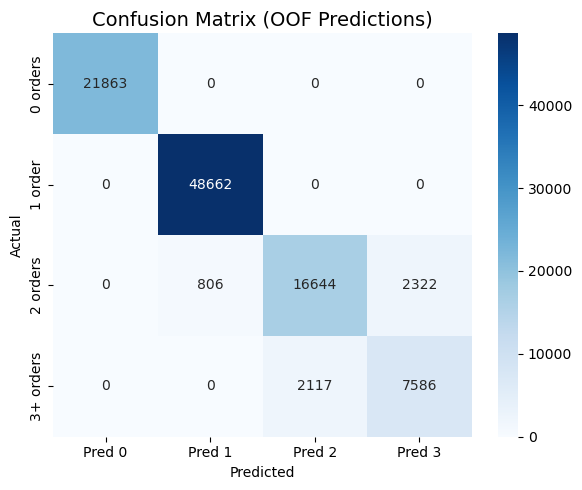

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# OOF 예측 결과 기반 confusion matrix
y_true = y
y_pred = oof_preds.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
cm_df = pd.DataFrame(cm,
                     index=["0 orders", "1 order", "2 orders", "3+ orders"],
                     columns=["Pred 0", "Pred 1", "Pred 2", "Pred 3"])

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (OOF Predictions)", fontsize=14)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

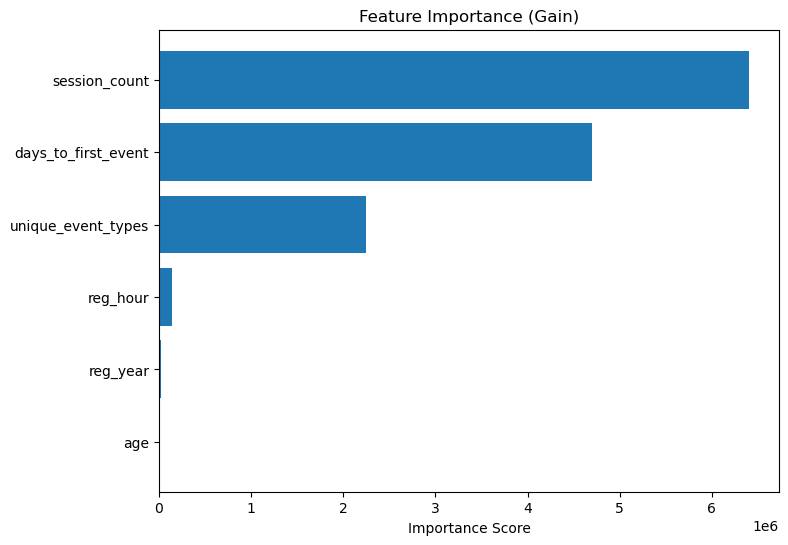

In [76]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# Feature importance (gain 기준)
importance = final_model.feature_importance(importance_type='gain')
feature_names = X[selected_feats].columns

# 정렬
indices = importance.argsort()[::-1]
plt.figure(figsize=(8, 6))
plt.title("Feature Importance (Gain)")
plt.barh(range(len(feature_names)), importance[indices], align="center")
plt.yticks(range(len(feature_names)), feature_names[indices])
plt.gca().invert_yaxis()  # 중요도가 높은 순서로 위에 오게
plt.xlabel("Importance Score")
plt.show()

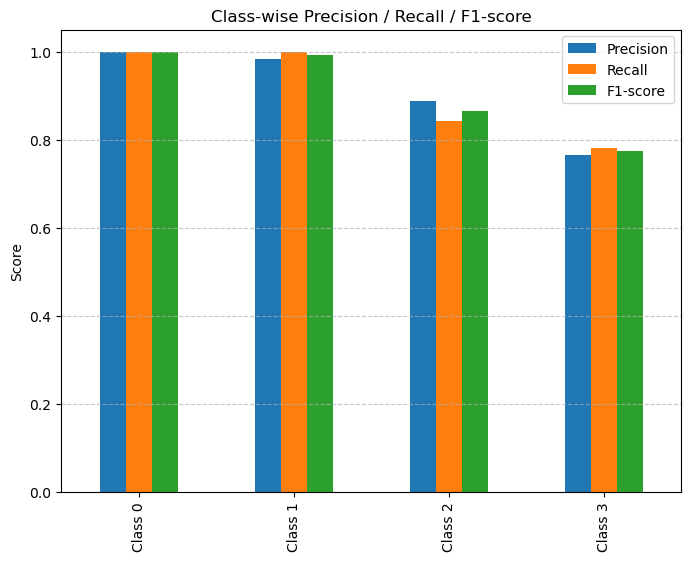

In [78]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# 클래스별 성능 계산
precisions = precision_score(y_true, y_pred, average=None)
recalls = recall_score(y_true, y_pred, average=None)
f1_scores = f1_score(y_true, y_pred, average=None)

metrics_df = pd.DataFrame({
    'Precision': precisions,
    'Recall': recalls,
    'F1-score': f1_scores
}, index=[f'Class {i}' for i in np.unique(y_true)])

metrics_df.plot(kind='bar', figsize=(8, 6))
plt.title("Class-wise Precision / Recall / F1-score")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

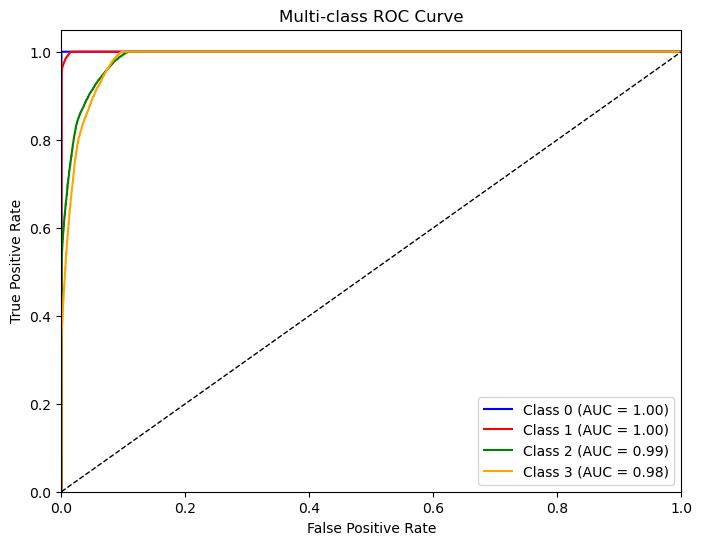

In [80]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# One-vs-Rest 방식
y_bin = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
colors = cycle(['blue', 'red', 'green', 'orange'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()

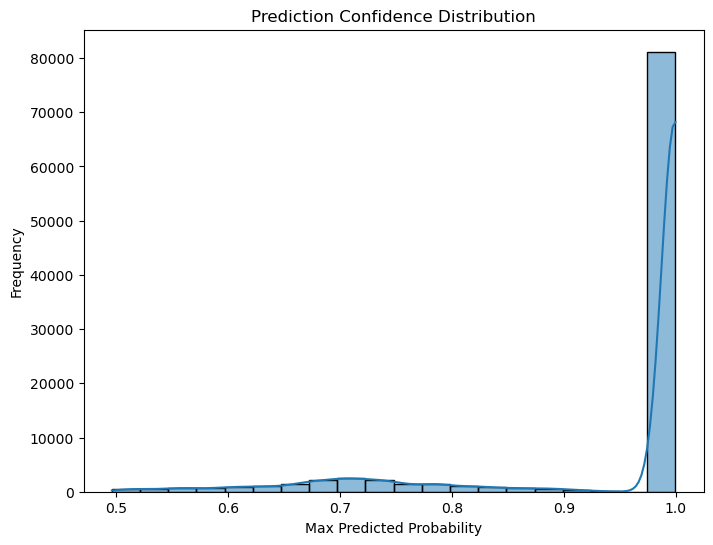

In [82]:
import seaborn as sns

# 예측 확률의 최대값 (모델이 얼마나 확신하는지)
max_proba = y_pred_proba.max(axis=1)

plt.figure(figsize=(8, 6))
sns.histplot(max_proba, bins=20, kde=True)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.show()